In [13]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns


In [14]:
sns.set_style("whitegrid")

In [15]:
df = pd.read_csv("listings.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20250914152803,2025-09-15,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,Apartment in Barcelona located in the heart of...,https://a0.muscache.com/pictures/13031453/413c...,71615,...,4.62,4.82,4.32,ESFCTU000008058000039706000000000000000HUTB-00...,t,26,26,0,0,0.34
1,23197,https://www.airbnb.com/rooms/23197,20250914152803,2025-09-14,city scrape,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",Beautiful and Spacious Apartment with Large Te...,"Strategically located in the Parc del Fòrum, a...",https://a0.muscache.com/pictures/miso/Hosting-...,90417,...,4.99,4.66,4.68,ESFCTU000008106000547162000000000000000000HUTB...,f,1,1,0,0,0.52
2,32711,https://www.airbnb.com/rooms/32711,20250914152803,2025-09-15,city scrape,Sagrada Familia area - Còrsega 1,A lovely two bedroom apartment only 250 m from...,What's nearby <br />This apartment is located...,https://a0.muscache.com/pictures/357b25e4-f414...,135703,...,4.89,4.89,4.47,HUTB-001722,f,2,2,0,0,0.88
3,34241,https://www.airbnb.com/rooms/34241,20250914152803,2025-09-15,city scrape,Stylish Top Floor Apartment - Ramblas Plaza Real,Located in close proximity to Plaza Real and L...,NaN,https://a0.muscache.com/pictures/2437facc-2fe7...,73163,...,4.68,4.73,4.23,Exempt,f,3,3,0,0,0.14
4,34981,https://www.airbnb.com/rooms/34981,20250914152803,2025-09-15,city scrape,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Spacious apartment for large families or group...,"Located in Ciutat Vella in the Gothic Quarter,...",https://a0.muscache.com/pictures/c4d1723c-e479...,73163,...,4.72,4.65,4.46,ESFCTU000008119000093652000000000000000HUTB-00...,f,3,3,0,0,1.49


In [16]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19410 entries, 0 to 19409
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            19410 non-null  int64  
 1   listing_url                                   19410 non-null  object 
 2   scrape_id                                     19410 non-null  int64  
 3   last_scraped                                  19410 non-null  object 
 4   source                                        19410 non-null  object 
 5   name                                          19410 non-null  object 
 6   description                                   18673 non-null  object 
 7   neighborhood_overview                         8986 non-null   object 
 8   picture_url                                   19410 non-null  object 
 9   host_id                                       19410 non-null 

In [17]:
df.isnull().sum().sort_values(ascending=False).head(10)

calendar_updated          19410
host_neighbourhood        10787
neighbourhood             10424
neighborhood_overview     10424
host_about                 7170
license                    5480
review_scores_checkin      4993
review_scores_accuracy     4992
review_scores_value        4992
review_scores_location     4992
dtype: int64

In [18]:
df = df.drop(columns=['calendar_updated'])

In [19]:
df = df.drop(columns=['host_neighbourhood'])
df = df.drop(columns=['neighborhood_overview'])

In [20]:
df = df.dropna(subset=['review_scores_location'])

In [21]:
df.shape


(14418, 76)

In [22]:
df.isnull().sum().sort_values(ascending=False).head(10)

neighbourhood              6776
host_about                 5115
host_location              3358
license                    3012
estimated_revenue_l365d    2628
price                      2628
beds                       2624
bathrooms                  2613
host_response_time         1767
host_response_rate         1767
dtype: int64

In [23]:
df = df.drop(columns=['neighbourhood',"host_about","license"])

In [24]:
df.isnull().sum().sort_values(ascending=False).head(10)

host_location              3358
price                      2628
estimated_revenue_l365d    2628
beds                       2624
bathrooms                  2613
host_response_time         1767
host_response_rate         1767
host_acceptance_rate       1481
bedrooms                   1209
description                 515
dtype: int64

In [25]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

In [26]:
df = df.dropna(subset=['price'])

In [27]:
df = df.drop(columns=['host_location',"estimated_revenue_l365d"])

In [29]:
df['beds'] = df['beds'].fillna(df['beds'].mean())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mean())

In [30]:
df.shape

(11790, 71)

In [31]:
df.isnull().sum().sort_values(ascending=False).head(10)

host_response_time        446
host_response_rate        446
description               386
host_is_superhost         280
host_acceptance_rate      266
has_availability           18
bedrooms                   11
bathrooms_text              6
minimum_minimum_nights      4
minimum_maximum_nights      4
dtype: int64

In [32]:
df[['beds', 'bathrooms']].isnull().sum()

beds         0
bathrooms    0
dtype: int64

In [33]:
df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(10)

neighbourhood_cleansed
el Coll                                         523.000000
Sants - Badal                                   384.629032
Navas                                           326.210526
el Besòs i el Maresme                           283.901408
Diagonal Mar i el Front Marítim del Poblenou    269.962617
la Font de la Guatlla                           258.222222
la Dreta de l'Eixample                          252.758710
la Vila Olímpica del Poblenou                   245.601942
el Poblenou                                     222.090062
Torre Baró                                      222.000000
Name: price, dtype: float64

In [34]:
df.groupby('neighbourhood_cleansed')['price'].agg(['mean', 'count']).sort_values(by='mean', ascending=False).head(10)

,mean,count
neighbourhood_cleansed,,
el Coll,523.000000,25
Sants - Badal,384.629032,124
Navas,326.210526,38
el Besòs i el Maresme,283.901408,71
Diagonal Mar i el Front Marítim del Poblenou,269.962617,107
la Font de la Guatlla,258.222222,72
la Dreta de l'Eixample,252.758710,1550
la Vila Olímpica del Poblenou,245.601942,103
el Poblenou,222.090062,322


In [42]:
top = df.groupby('neighbourhood_cleansed').agg({
    'price': 'mean',
    'id': 'count'
}).rename(columns={'id': 'count'})

top = top[top['count'] > 50]

top = top.sort_values(by='price', ascending=False).head(10)

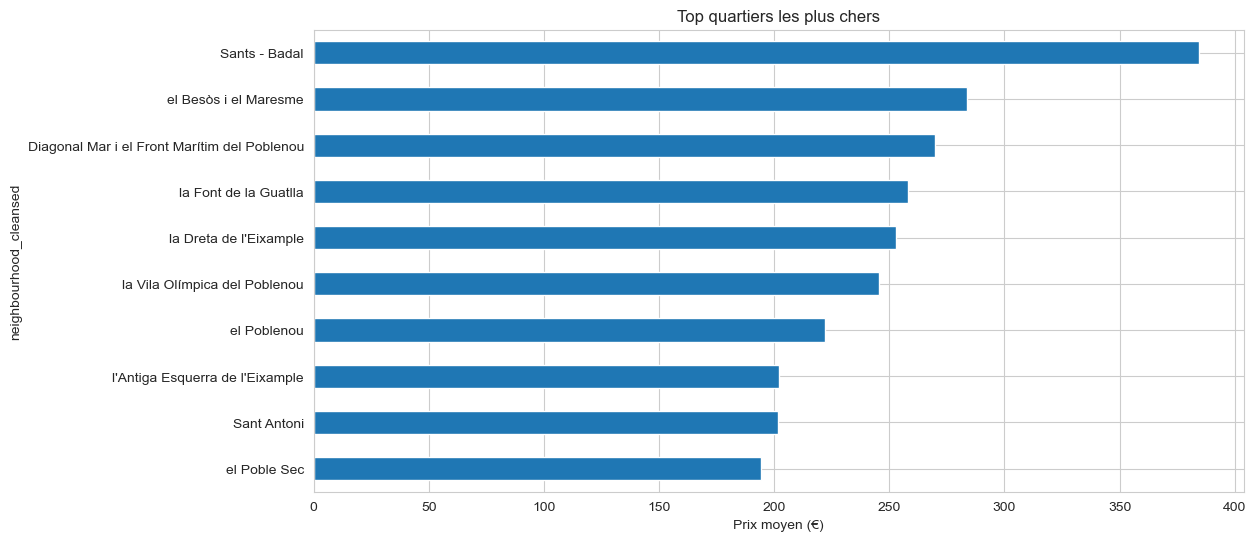

In [51]:
plt.figure(figsize=(12,6))

top['price'].sort_values().plot(kind='barh')

plt.title("Top quartiers les plus chers")
plt.xlabel("Prix moyen (€)")

plt.show()

In [39]:
df.groupby('room_type')['price'].mean().sort_values()

room_type
Shared room         89.215909
Private room        93.736909
Entire home/apt    220.445712
Hotel room         223.940000
Name: price, dtype: float64

In [47]:
df['price'].describe()

count    11790.000000
mean       185.616794
std        320.687058
min         10.000000
25%         73.000000
50%        146.000000
75%        225.000000
max      10000.000000
Name: price, dtype: float64

In [48]:
df.groupby('bedrooms')['price'].mean()

bedrooms
0.0      194.099256
1.0      126.176723
2.0      197.335575
3.0      238.481940
4.0      313.593388
5.0      499.367521
6.0      655.377358
7.0      664.000000
8.0     1132.800000
9.0     1394.000000
10.0     725.666667
12.0    1548.833333
15.0    1875.000000
Name: price, dtype: float64

In [53]:
df = df[df['price'] < 1200]

In [54]:
df['price'].describe()

count    11732.000000
mean       170.646096
std        134.560355
min         10.000000
25%         73.000000
50%        145.000000
75%        224.000000
max       1184.000000
Name: price, dtype: float64

In [55]:
df['bedrooms'].value_counts()

bedrooms
1.0     5337
2.0     3267
3.0     1932
4.0      601
0.0      401
5.0      115
6.0       51
8.0        7
7.0        5
9.0        3
10.0       2
Name: count, dtype: int64

In [56]:
df_bed = df[df['bedrooms'] <= 6]

In [57]:
df_bed.groupby('bedrooms')['price'].mean()

bedrooms
0.0    149.885287
1.0    113.332959
2.0    189.836853
3.0    225.385093
4.0    305.677205
5.0    472.278261
6.0    628.745098
Name: price, dtype: float64

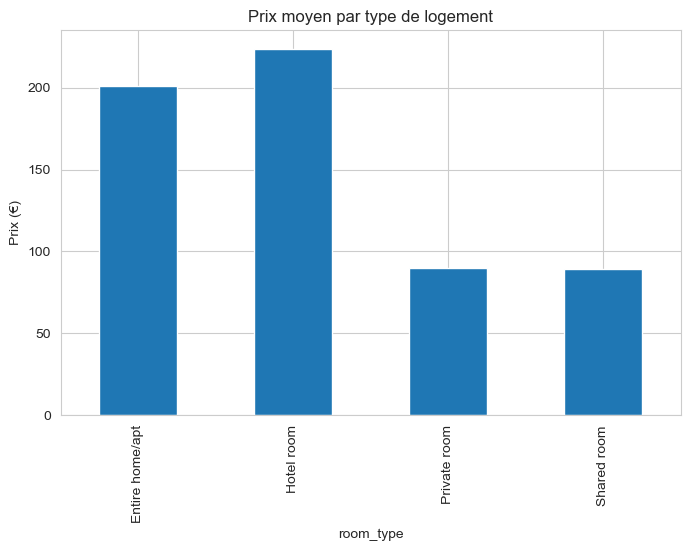

In [58]:
plt.figure(figsize=(8,5))

df.groupby('room_type')['price'].mean().plot(kind='bar')

plt.title("Prix moyen par type de logement")
plt.ylabel("Prix (€)")

plt.show()

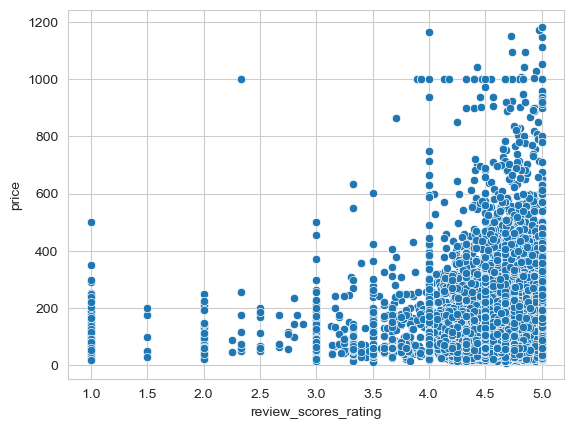

In [59]:
sns.scatterplot(x='review_scores_rating', y='price', data=df)
plt.show()